# Grad-CAM comparison of Models A and C

This notebook compares the baseline model with the low-light-augmented model using Grad-CAM. The goal is to inspect which image regions contribute to the true emotion class before and after severe low-light corruption.

Two small, clearly separated example sets are used:

1. A fixed class-balanced sample chosen without looking at the severe predictions.
2. Recovery cases where Model C is correct and Model A is wrong under severe low light.

The second set is intentionally selected to illustrate recoveries and is not presented as representative evidence. The quantitative robustness results remain the main evidence.

In [1]:
from pathlib import Path
import json
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display

SEED = 42
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"Python: {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

Python: 3.13.15
TensorFlow: 2.20.0
GPU available: True


## Paths and settings

Only Models A and C are needed here. They have the same EfficientNetB0 architecture and classifier head, so their heatmaps can be compared at the same convolutional layer.

The clean and severe conditions below match the earlier paired robustness evaluation.

In [2]:
CLASS_NAMES = ['angry', 'happy', 'sad']
MODEL_LABELS = {
    'A': 'Model A: baseline',
    'C': 'Model C: low light',
}

DRIVE_DATASET_DIR = Path('/content/drive/MyDrive/Emotions Dataset')
LOCAL_TEST_DIR = Path('/content/emotions_dataset/test')
PROJECT_OUTPUT_DIR = Path(
    '/content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs'
)
OUTPUT_DIR = PROJECT_OUTPUT_DIR / 'gradcam'

MODEL_PATHS = {
    'A': PROJECT_OUTPUT_DIR / 'model_a' / 'model_a_baseline.keras',
    'C': (
        PROJECT_OUTPUT_DIR
        / 'model_c'
        / 'model_c_low_light_augmentation.keras'
    ),
}

CONDITIONS = {
    'clean': {
        'label': 'Clean',
        'gamma': 1.00,
        'exposure': 1.00,
        'noise_stddev': 0.00,
    },
    'severe': {
        'label': 'Severe',
        'gamma': 1.80,
        'exposure': 0.55,
        'noise_stddev': 0.03,
    },
}

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
HEATMAP_ALPHA = 0.40

display(pd.DataFrame(CONDITIONS).T)

,label,gamma,exposure,noise_stddev
clean,Clean,1.0,1.0,0.0
severe,Severe,1.8,0.55,0.03


## Load the untouched test set

The test images are copied to the Colab runtime only for faster reading. Their order is fixed, which lets this notebook reproduce the same stateless severe-noise field used in the robustness evaluation.

In [3]:
from google.colab import drive

drive.mount('/content/drive')

drive_test_dir = DRIVE_DATASET_DIR / 'test'
required_test_directories = [
    drive_test_dir / class_name
    for class_name in CLASS_NAMES
]
missing_directories = [
    directory for directory in required_test_directories
    if not directory.is_dir()
]
missing_models = [
    model_path
    for model_path in MODEL_PATHS.values()
    if not model_path.is_file()
]

if missing_directories:
    missing_text = '\n'.join(str(path) for path in missing_directories)
    raise FileNotFoundError(
        f"The following test folders were not found:\n{missing_text}"
    )

if missing_models:
    missing_text = '\n'.join(str(path) for path in missing_models)
    raise FileNotFoundError(
        f"The following model checkpoints were not found:\n{missing_text}"
    )

if not LOCAL_TEST_DIR.exists():
    LOCAL_TEST_DIR.parent.mkdir(parents=True, exist_ok=True)
    print('Copying the test set to the Colab runtime...')
    shutil.copytree(drive_test_dir, LOCAL_TEST_DIR)
    print('Copy complete.')
else:
    print('Using the test set already copied to the Colab runtime.')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    LOCAL_TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=CLASS_NAMES,
    shuffle=False,
)

test_file_paths = list(test_dataset.file_paths)
relative_test_files = [
    str(Path(file_path).relative_to(LOCAL_TEST_DIR))
    for file_path in test_file_paths
]
true_labels = np.concatenate([
    np.argmax(batch_labels.numpy(), axis=1)
    for _, batch_labels in test_dataset
])

print(f"Test images: {len(true_labels)}")
print(f"Class order: {CLASS_NAMES}")

Mounted at /content/drive
Copying the test set to the Colab runtime...
Copy complete.
Found 2278 files belonging to 3 classes.
Test images: 2278
Class order: ['angry', 'happy', 'sad']


## Reproduce the paired image conditions

Pixels are converted from 0-255 to 0-1 before applying gamma, exposure, and normalized Gaussian noise. The batch index is part of the stateless seed. As a result, each model receives identical corrupted pixels.

In [4]:
def apply_fixed_condition(images, batch_index, settings):
    images = tf.cast(images, tf.float32) / 255.0
    images = tf.clip_by_value(images, 0.0, 1.0)

    seed = tf.stack([
        tf.constant(SEED, dtype=tf.int64),
        tf.cast(batch_index, tf.int64),
    ])
    base_noise = tf.random.stateless_normal(
        shape=tf.shape(images),
        seed=seed,
        dtype=tf.float32,
    )

    corrupted = (
        settings['exposure'] * tf.pow(images, settings['gamma'])
        + settings['noise_stddev'] * base_noise
    )
    return tf.clip_by_value(corrupted, 0.0, 1.0) * 255.0


def make_condition_dataset(settings):
    def transform(batch_index, batch):
        images, labels = batch
        condition_images = apply_fixed_condition(
            images,
            batch_index,
            settings,
        )
        return condition_images, labels

    return (
        test_dataset
        .enumerate()
        .map(
            transform,
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=True,
        )
        .prefetch(tf.data.AUTOTUNE)
    )


condition_datasets = {
    condition_name: make_condition_dataset(settings)
    for condition_name, settings in CONDITIONS.items()
}

## Generate predictions before choosing examples

The selection rules use predictions only, not Grad-CAM heatmaps. This avoids searching through heatmaps for visually convenient examples.

In [5]:
models = {
    model_key: tf.keras.models.load_model(
        str(model_path),
        compile=False,
    )
    for model_key, model_path in MODEL_PATHS.items()
}

probabilities_by_key = {}
predictions_by_key = {}
accuracy_rows = []

for model_key, model in models.items():
    for condition_name, condition_dataset in condition_datasets.items():
        probabilities = model.predict(
            condition_dataset,
            verbose=0,
        )
        predictions = np.argmax(probabilities, axis=1)

        probabilities_by_key[(model_key, condition_name)] = probabilities
        predictions_by_key[(model_key, condition_name)] = predictions
        accuracy_rows.append({
            'model': model_key,
            'condition': condition_name,
            'accuracy': float(np.mean(predictions == true_labels)),
        })

accuracy_table = (
    pd.DataFrame(accuracy_rows)
    .pivot(index='model', columns='condition', values='accuracy')
    .reindex(index=['A', 'C'], columns=['clean', 'severe'])
)

display(accuracy_table.style.format('{:.4f}'))

condition,clean,severe
model,,
A,0.8169,0.7142
C,0.8161,0.7687


## Select fixed examples and severe recovery cases

For the fixed sample, one image per class is selected with a seeded random generator from images that both models classify correctly when clean. Severe predictions do not affect this selection.

For the recovery set, one image per class is selected from cases where C is correct and A is wrong under severe low light. The selected image has the median improvement in true-class probability within that group, rather than the most dramatic improvement.

In [6]:
rng = np.random.default_rng(SEED)
selection_rows = []

for class_index, class_name in enumerate(CLASS_NAMES):
    fixed_candidates = np.flatnonzero(
        (true_labels == class_index)
        & (
            predictions_by_key[('A', 'clean')]
            == class_index
        )
        & (
            predictions_by_key[('C', 'clean')]
            == class_index
        )
    )

    if len(fixed_candidates) == 0:
        raise RuntimeError(
            f"No fixed-sample candidate was found for {class_name}."
        )

    fixed_index = int(rng.choice(fixed_candidates))
    selection_rows.append({
        'selection': 'fixed',
        'index': fixed_index,
        'file': relative_test_files[fixed_index],
        'true_label': class_name,
        'selection_rule': (
            'Seeded random choice among images both models '
            'classify correctly when clean'
        ),
    })

    recovery_candidates = np.flatnonzero(
        (true_labels == class_index)
        & (
            predictions_by_key[('A', 'severe')]
            != class_index
        )
        & (
            predictions_by_key[('C', 'severe')]
            == class_index
        )
    )

    if len(recovery_candidates) == 0:
        raise RuntimeError(
            f"No severe recovery candidate was found for {class_name}."
        )

    true_probability_gain = (
        probabilities_by_key[('C', 'severe')][
            recovery_candidates,
            class_index,
        ]
        - probabilities_by_key[('A', 'severe')][
            recovery_candidates,
            class_index,
        ]
    )
    ordered_candidates = recovery_candidates[
        np.argsort(true_probability_gain)
    ]
    recovery_index = int(
        ordered_candidates[len(ordered_candidates) // 2]
    )

    selection_rows.append({
        'selection': 'recovery',
        'index': recovery_index,
        'file': relative_test_files[recovery_index],
        'true_label': class_name,
        'selection_rule': (
            'Median true-class probability gain among severe '
            'cases where C is correct and A is wrong'
        ),
    })

selected_examples = pd.DataFrame(selection_rows)

for model_key in ['A', 'C']:
    for condition_name in ['clean', 'severe']:
        predictions = predictions_by_key[
            (model_key, condition_name)
        ]
        probabilities = probabilities_by_key[
            (model_key, condition_name)
        ]

        selected_examples[
            f'{model_key}_{condition_name}_prediction'
        ] = [
            CLASS_NAMES[predictions[index]]
            for index in selected_examples['index']
        ]
        selected_examples[
            f'{model_key}_{condition_name}_true_probability'
        ] = [
            float(
                probabilities[
                    index,
                    CLASS_NAMES.index(true_label),
                ]
            )
            for index, true_label in zip(
                selected_examples['index'],
                selected_examples['true_label'],
            )
        ]

display(selected_examples)

,selection,index,file,true_label,selection_rule,A_clean_prediction,A_clean_true_probability,A_severe_prediction,A_severe_true_probability,C_clean_prediction,C_clean_true_probability,C_severe_prediction,C_severe_true_probability
0,fixed,48,angry/159595.jpg_rotation_1.jpg,angry,Seeded random choice among images both models ...,angry,0.865299,sad,0.235329,angry,0.707757,sad,0.395345
1,recovery,121,angry/260208.jpg_brightness_1.jpg,angry,Median true-class probability gain among sever...,angry,0.987461,sad,0.446386,angry,0.971438,angry,0.869425
2,fixed,1297,happy/816366.jpg_brightness_2.jpg,happy,Seeded random choice among images both models ...,happy,0.999980,happy,0.978033,happy,0.999823,happy,0.995234
3,recovery,1006,happy/562970.jpg,happy,Median true-class probability gain among sever...,happy,0.946868,sad,0.224508,happy,0.953168,happy,0.629421
4,fixed,2021,sad/693655.jpg_brightness_1.jpg,sad,Seeded random choice among images both models ...,sad,0.935937,sad,0.949493,sad,0.632154,sad,0.918167
5,recovery,1713,sad/327081.jpg_rotation_2.jpg,sad,Median true-class probability gain among sever...,happy,0.312639,happy,0.284386,sad,0.460138,sad,0.805853


## Build the Grad-CAM explainers

Grad-CAM weights the final convolutional feature maps using the gradient of a chosen class score. Here the chosen score is always the true class, which keeps comparisons consistent even when a model predicts the wrong class.

The final Dense layer uses softmax, so its logits are reconstructed from its stored kernel and bias for the gradient calculation. The reconstructed probabilities are checked against the model output.

The backbone is marked trainable only so TensorFlow records its gradient path. Every forward call uses training=False, and no optimizer or weight update is used.

In [7]:
def find_backbone(model):
    candidates = [
        layer for layer in model.layers
        if isinstance(layer, tf.keras.Model)
        and 'efficientnet' in layer.name.lower()
    ]

    if len(candidates) != 1:
        layer_names = [layer.name for layer in model.layers]
        raise RuntimeError(
            'Expected one nested EfficientNet backbone. '
            f'Found these top-level layers: {layer_names}'
        )

    return candidates[0]


def build_gradcam_explainer(model):
    backbone = find_backbone(model)
    backbone.trainable = True

    try:
        last_conv_layer = backbone.get_layer('top_conv')
    except ValueError as error:
        raise RuntimeError(
            f"The layer top_conv was not found in {backbone.name}."
        ) from error

    feature_model = tf.keras.Model(
        backbone.input,
        [last_conv_layer.output, backbone.output],
    )

    backbone_position = model.layers.index(backbone)
    head_layers = model.layers[backbone_position + 1:]
    final_layer = head_layers[-1]

    if not isinstance(final_layer, tf.keras.layers.Dense):
        raise RuntimeError(
            'The final classifier layer is not a Dense layer.'
        )

    hidden_layers = head_layers[:-1]

    def explain(image_batch, class_index):
        image_batch = tf.cast(image_batch, tf.float32)

        with tf.GradientTape() as tape:
            convolution_output, features = feature_model(
                image_batch,
                training=False,
            )

            hidden = features
            for layer in hidden_layers:
                if isinstance(layer, tf.keras.layers.Dropout):
                    hidden = layer(hidden, training=False)
                else:
                    hidden = layer(hidden)

            logits = tf.linalg.matmul(hidden, final_layer.kernel)
            if final_layer.use_bias:
                logits = tf.nn.bias_add(logits, final_layer.bias)

            class_score = logits[:, class_index]

        gradients = tape.gradient(
            class_score,
            convolution_output,
        )

        if gradients is None:
            raise RuntimeError(
                'TensorFlow could not calculate the Grad-CAM gradients.'
            )

        channel_weights = tf.reduce_mean(
            gradients,
            axis=(1, 2),
            keepdims=True,
        )
        heatmap = tf.reduce_sum(
            channel_weights * convolution_output,
            axis=-1,
        )
        heatmap = tf.nn.relu(heatmap)
        heatmap = tf.math.divide_no_nan(
            heatmap,
            tf.reduce_max(
                heatmap,
                axis=(1, 2),
                keepdims=True,
            ),
        )

        reconstructed_probabilities = tf.nn.softmax(logits)
        model_probabilities = model(
            image_batch,
            training=False,
        )

        np.testing.assert_allclose(
            reconstructed_probabilities.numpy(),
            model_probabilities.numpy(),
            rtol=1e-5,
            atol=1e-6,
        )

        return (
            heatmap[0].numpy(),
            reconstructed_probabilities[0].numpy(),
        )

    return {
        'backbone': backbone,
        'last_conv_layer': last_conv_layer.name,
        'explain': explain,
    }


gradcam_tools = {
    model_key: build_gradcam_explainer(model)
    for model_key, model in models.items()
}

print({
    model_key: tools['last_conv_layer']
    for model_key, tools in gradcam_tools.items()
})

{'A': 'top_conv', 'C': 'top_conv'}


In [8]:
batch_cache = {}


def get_test_batch(batch_index):
    if batch_index not in batch_cache:
        batch_cache[batch_index] = next(iter(
            test_dataset
            .skip(batch_index)
            .take(1)
        ))
    return batch_cache[batch_index]


def get_condition_image(image_index, condition_name):
    batch_index = image_index // BATCH_SIZE
    position_in_batch = image_index % BATCH_SIZE
    batch_images, _ = get_test_batch(batch_index)

    condition_images = apply_fixed_condition(
        batch_images,
        tf.constant(batch_index, dtype=tf.int64),
        CONDITIONS[condition_name],
    )
    return condition_images[
        position_in_batch:position_in_batch + 1
    ]


def overlay_heatmap(image_batch, heatmap, alpha=HEATMAP_ALPHA):
    image = np.clip(
        image_batch[0].numpy() / 255.0,
        0.0,
        1.0,
    )
    resized_heatmap = tf.image.resize(
        heatmap[None, :, :, None],
        IMAGE_SIZE,
        method='bilinear',
    )[0, :, :, 0].numpy()

    heatmap_color = plt.get_cmap('jet')(
        resized_heatmap
    )[:, :, :3]

    return np.clip(
        (1.0 - alpha) * image + alpha * heatmap_color,
        0.0,
        1.0,
    )


def explain_selected_image(
    model_key,
    image_index,
    condition_name,
    true_class_index,
):
    image_batch = get_condition_image(
        image_index,
        condition_name,
    )
    heatmap, probabilities = gradcam_tools[
        model_key
    ]['explain'](
        image_batch,
        true_class_index,
    )
    overlay = overlay_heatmap(image_batch, heatmap)

    predicted_index = int(np.argmax(probabilities))
    return {
        'image': image_batch[0].numpy(),
        'overlay': overlay,
        'prediction': CLASS_NAMES[predicted_index],
        'true_probability': float(
            probabilities[true_class_index]
        ),
    }

## Fixed class-balanced examples

These examples were chosen without using severe predictions. The heatmaps target the true class. They are useful for inspecting whether attention changes under illumination shift, but three images cannot establish a population-level effect.

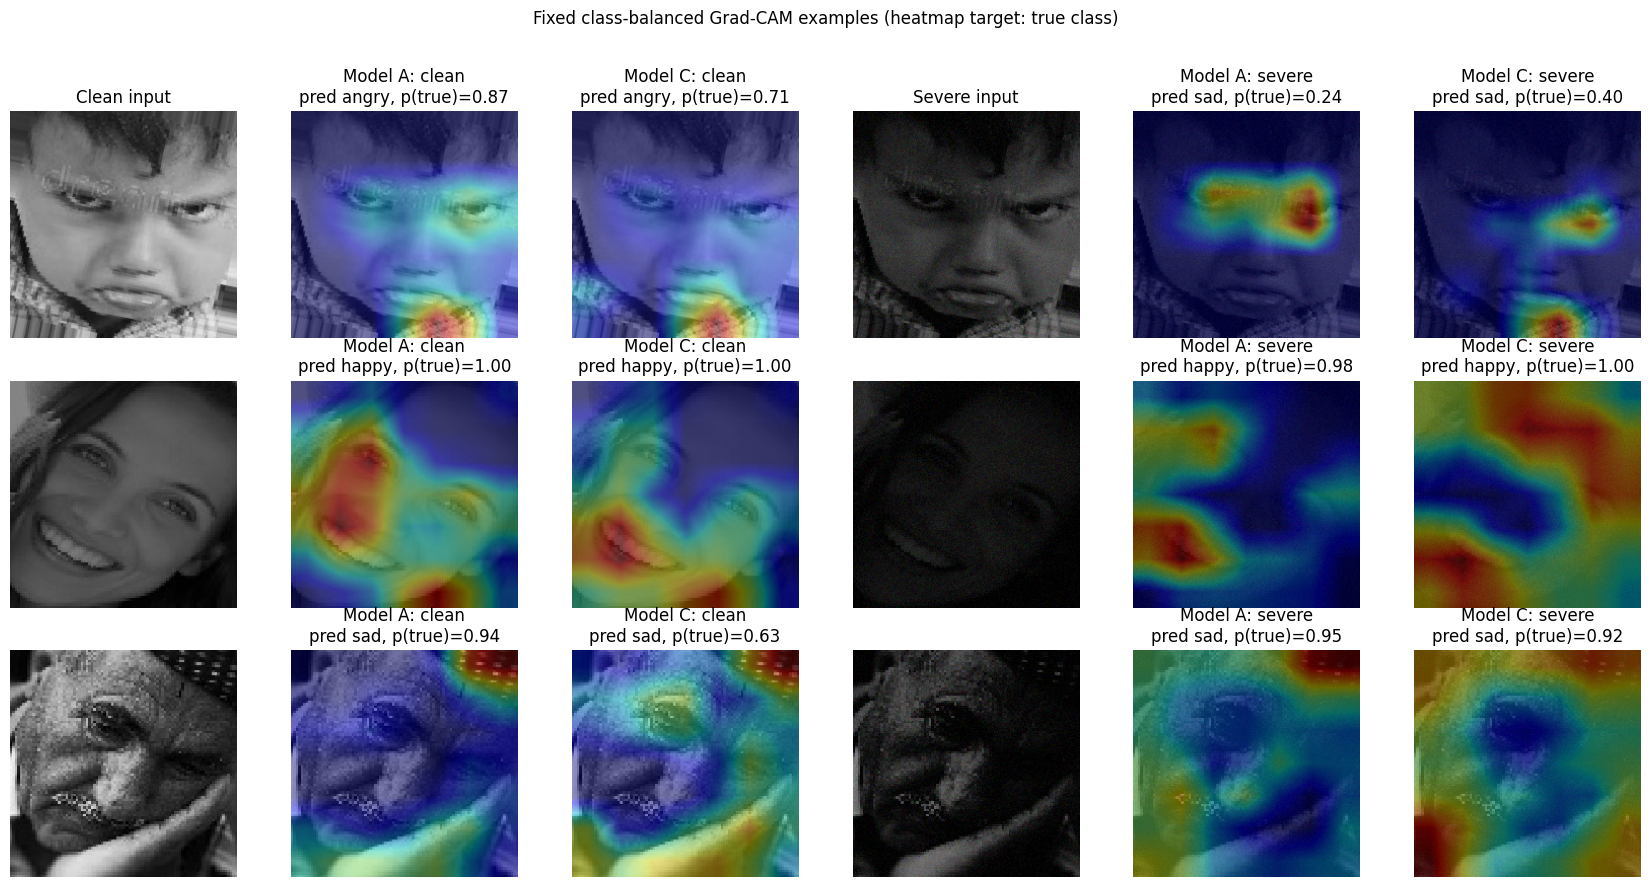

In [9]:
fixed_examples = (
    selected_examples[selected_examples['selection'] == 'fixed']
    .set_index('true_label')
    .loc[CLASS_NAMES]
    .reset_index()
)

column_specs = [
    ('input', 'clean', None, 'Clean input'),
    ('cam', 'clean', 'A', 'Model A: clean'),
    ('cam', 'clean', 'C', 'Model C: clean'),
    ('input', 'severe', None, 'Severe input'),
    ('cam', 'severe', 'A', 'Model A: severe'),
    ('cam', 'severe', 'C', 'Model C: severe'),
]

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    len(column_specs),
    figsize=(17, 9),
)

for row_index, example in fixed_examples.iterrows():
    image_index = int(example['index'])
    true_label = example['true_label']
    true_class_index = CLASS_NAMES.index(true_label)

    for column_index, (
        panel_type,
        condition_name,
        model_key,
        column_title,
    ) in enumerate(column_specs):
        axis = axes[row_index, column_index]

        if panel_type == 'input':
            image_batch = get_condition_image(
                image_index,
                condition_name,
            )
            axis.imshow(
                image_batch[0].numpy().astype('uint8')
            )
            if row_index == 0:
                axis.set_title(column_title)
        else:
            explanation = explain_selected_image(
                model_key,
                image_index,
                condition_name,
                true_class_index,
            )
            axis.imshow(explanation['overlay'])
            axis.set_title(
                f"{column_title}\n"
                f"pred {explanation['prediction']}, "
                f"p(true)={explanation['true_probability']:.2f}"
            )

        axis.axis('off')

    axes[row_index, 0].set_ylabel(
        f"True: {true_label}",
        fontsize=12,
    )

fig.suptitle(
    'Fixed class-balanced Grad-CAM examples '
    '(heatmap target: true class)'
)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(
    OUTPUT_DIR / 'fixed_class_examples.png',
    dpi=200,
    bbox_inches='tight',
)
plt.show()

## Severe recovery cases

Each row now shows a case where Model C is correct and Model A is wrong under severe low light. These panels illustrate individual recoveries. They should accompany, not replace, the paired accuracy results from the full test set.

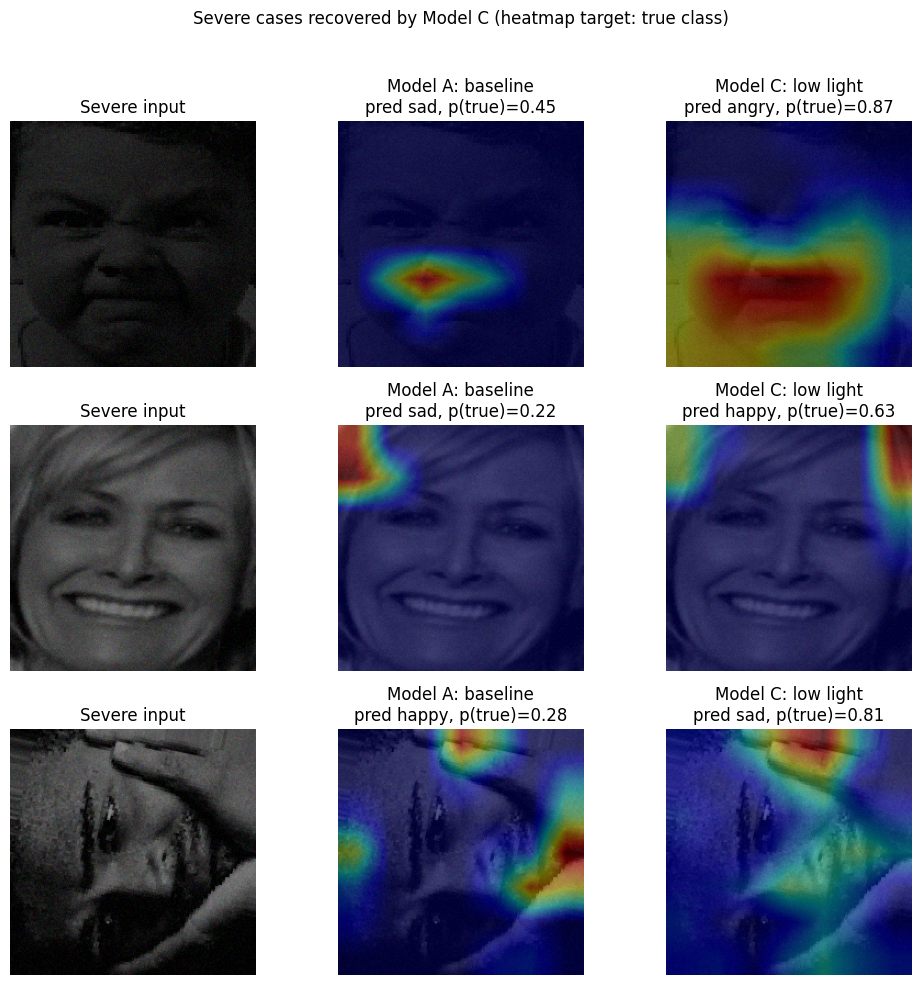

In [10]:
recovery_examples = (
    selected_examples[
        selected_examples['selection'] == 'recovery'
    ]
    .set_index('true_label')
    .loc[CLASS_NAMES]
    .reset_index()
)

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    3,
    figsize=(10, 10),
)

for row_index, example in recovery_examples.iterrows():
    image_index = int(example['index'])
    true_label = example['true_label']
    true_class_index = CLASS_NAMES.index(true_label)
    severe_image = get_condition_image(
        image_index,
        'severe',
    )

    axes[row_index, 0].imshow(
        severe_image[0].numpy().astype('uint8')
    )
    axes[row_index, 0].set_title('Severe input')
    axes[row_index, 0].axis('off')
    axes[row_index, 0].set_ylabel(
        f"True: {true_label}",
        fontsize=12,
    )

    for column_index, model_key in enumerate(
        ['A', 'C'],
        start=1,
    ):
        explanation = explain_selected_image(
            model_key,
            image_index,
            'severe',
            true_class_index,
        )
        axes[row_index, column_index].imshow(
            explanation['overlay']
        )
        axes[row_index, column_index].set_title(
            f"{MODEL_LABELS[model_key]}\n"
            f"pred {explanation['prediction']}, "
            f"p(true)={explanation['true_probability']:.2f}"
        )
        axes[row_index, column_index].axis('off')

fig.suptitle(
    'Severe cases recovered by Model C '
    '(heatmap target: true class)'
)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(
    OUTPUT_DIR / 'severe_recovery_examples.png',
    dpi=200,
    bbox_inches='tight',
)
plt.show()

## Save the selection and analysis details

The CSV records exactly how every displayed image was chosen. This makes the qualitative analysis auditable and prevents the examples from being mistaken for a random sample.

In [11]:
selected_examples.to_csv(
    OUTPUT_DIR / 'selected_examples.csv',
    index=False,
)

gradcam_summary = {
    'experiment': 'Grad-CAM comparison of Models A and C',
    'seed': SEED,
    'tensorflow_version': tf.__version__,
    'model_paths': {
        key: str(path)
        for key, path in MODEL_PATHS.items()
    },
    'conditions': CONDITIONS,
    'heatmap_target': 'True class logit',
    'last_convolutional_layers': {
        model_key: tools['last_conv_layer']
        for model_key, tools in gradcam_tools.items()
    },
    'fixed_selection_rule': (
        'One seeded random image per class among images that '
        'both models classify correctly when clean'
    ),
    'recovery_selection_rule': (
        'One median true-class probability-gain image per class '
        'among severe cases where C is correct and A is wrong'
    ),
    'qualitative_analysis_only': True,
    'selected_examples': json.loads(
        selected_examples.to_json(orient='records')
    ),
    'accuracy_check': json.loads(
        accuracy_table.reset_index().to_json(orient='records')
    ),
    'saved_figures': [
        'fixed_class_examples.png',
        'severe_recovery_examples.png',
    ],
}

with open(OUTPUT_DIR / 'gradcam_summary.json', 'w') as file:
    json.dump(gradcam_summary, file, indent=2)

print(f"Saved all Grad-CAM outputs to: {OUTPUT_DIR}")

Saved all Grad-CAM outputs to: /content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs/gradcam
